In [1]:
import pandas as pd
import numpy as np

# ============================================================
# Load malicious random 10% dataset
# ============================================================

det_path = "uav_detection_random_10_lessstrict.csv"
rl_path = "uav_rl_random_10_lessstrict.csv"

det_df = pd.read_csv(det_path)
rl_df = pd.read_csv(rl_path)

print("===== DATASET SHAPES =====")
print("Detection shape:", det_df.shape)
print("RL shape:", rl_df.shape)

print("\n===== DETECTION COLUMNS =====")
print(det_df.columns.tolist())

print("\n===== RL COLUMNS =====")
print(rl_df.columns.tolist())

# ============================================================
# Expected row checks
# ============================================================

expected_detection_rows = 4 * 3 * 120 * 20 * 19
expected_rl_rows = 4 * 3 * 120 * 20

print("\n===== EXPECTED ROW CHECK =====")
print("Expected detection rows:", expected_detection_rows)
print("Actual detection rows:", len(det_df))
print("Detection row check:", "PASS" if len(det_df) == expected_detection_rows else "FAIL")

print("\nExpected RL rows:", expected_rl_rows)
print("Actual RL rows:", len(rl_df))
print("RL row check:", "PASS" if len(rl_df) == expected_rl_rows else "FAIL")

# ============================================================
# Label / flag checks
# ============================================================

print("\n===== LABEL COUNTS =====")
print("actual_target_malicious:")
print(det_df["actual_target_malicious"].value_counts().sort_index())

print("\nreceiver_malicious:")
print(det_df["receiver_malicious"].value_counts().sort_index())

print("\nphase1_fail:")
print(det_df["phase1_fail"].value_counts().sort_index())

print("\nphase2_fail:")
print(det_df["phase2_fail"].value_counts().sort_index())

print("\nfinal_flag:")
print(det_df["final_flag"].value_counts().sort_index())

# ============================================================
# NaN / Inf checks
# ============================================================

numeric_det = det_df.select_dtypes(include=[np.number])
numeric_rl = rl_df.select_dtypes(include=[np.number])

print("\n===== NaN CHECK =====")
print("Detection total NaN:", det_df.isna().sum().sum())
print("RL total NaN:", rl_df.isna().sum().sum())

print("\n===== INF CHECK =====")
print("Detection total Inf:", np.isinf(numeric_det).sum().sum())
print("RL total Inf:", np.isinf(numeric_rl).sum().sum())

print("\n===== ENVIRONMENT COUNTS =====")
print(det_df["envId"].value_counts().sort_index())

print("\n===== FORMATION COUNTS =====")
print(det_df["formationType"].value_counts().sort_index())

===== DATASET SHAPES =====
Detection shape: (547200, 19)
RL shape: (28800, 14)

===== DETECTION COLUMNS =====
['envId', 'formationType', 'timeStep', 'receiverId', 'targetId', 'd_true', 'd_gps', 'd_rssi', 'delta_d', 'phase1_fail', 'jury1', 'jury2', 'jury3', 'maxResidual', 'phase2_fail', 'final_flag', 'actual_target_malicious', 'receiver_malicious', 'malicious_ratio']

===== RL COLUMNS =====
['envId', 'formationType', 'timeStep', 'receiverId', 'sigma_rssi_bar', 'sigma_gps_bar', 'snr_bar', 'plr_bar', 'relative_speed_bar', 'relative_height_bar', 'trusted_count', 'trust_bar', 'theta', 'malicious_ratio']

===== EXPECTED ROW CHECK =====
Expected detection rows: 547200
Actual detection rows: 547200
Detection row check: PASS

Expected RL rows: 28800
Actual RL rows: 28800
RL row check: PASS

===== LABEL COUNTS =====
actual_target_malicious:
actual_target_malicious
0    492480
1     54720
Name: count, dtype: int64

receiver_malicious:
receiver_malicious
0    492480
1     54720
Name: count, dtype:

In [2]:
import numpy as np
import pandas as pd

# ============================================================
# Safe metric function
# ============================================================

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))
    TP = int(np.sum((y_true == 1) & (y_pred == 1)))

    total = TN + FP + FN + TP

    accuracy = (TP + TN) / total if total > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if not np.isnan(precision) and not np.isnan(recall) and (precision + recall) > 0
        else np.nan
    )
    fp_rate = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    fn_rate = FN / (FN + TP) if (FN + TP) > 0 else np.nan

    return {
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fp_rate": fp_rate,
        "fn_rate": fn_rate,
    }


def print_metrics(title, metrics):
    print(f"\n===== {title} =====")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")


# ============================================================
# Overall metrics
# ============================================================

y_true = det_df["actual_target_malicious"].astype(int)

phase1_metrics = compute_metrics(y_true, det_df["phase1_fail"].astype(int))
phase2_metrics = compute_metrics(y_true, det_df["phase2_fail"].astype(int))
final_metrics = compute_metrics(y_true, det_df["final_flag"].astype(int))

print_metrics("PHASE 1 ONLY METRICS", phase1_metrics)
print_metrics("PHASE 2 ONLY METRICS", phase2_metrics)
print_metrics("FINAL DETECTION METRICS", final_metrics)

# Save
overall_metrics_df = pd.DataFrame([
    {"method": "phase1_only", **phase1_metrics},
    {"method": "phase2_only", **phase2_metrics},
    {"method": "final_phase1_or_phase2", **final_metrics},
])

overall_metrics_df.to_csv("random_10_overall_metrics.csv", index=False)

print("\nSaved:")
print("random_10_overall_metrics.csv")


===== PHASE 1 ONLY METRICS =====
TN: 338326
FP: 154154
FN: 8804
TP: 45916
accuracy: 0.7022
precision: 0.2295
recall: 0.8391
f1: 0.3604
fp_rate: 0.3130
fn_rate: 0.1609

===== PHASE 2 ONLY METRICS =====
TN: 320935
FP: 171545
FN: 48718
TP: 6002
accuracy: 0.5975
precision: 0.0338
recall: 0.1097
f1: 0.0517
fp_rate: 0.3483
fn_rate: 0.8903

===== FINAL DETECTION METRICS =====
TN: 166781
FP: 325699
FN: 2802
TP: 51918
accuracy: 0.3997
precision: 0.1375
recall: 0.9488
f1: 0.2402
fp_rate: 0.6613
fn_rate: 0.0512

Saved:
random_10_overall_metrics.csv


In [3]:
# ============================================================
# Phase contribution analysis
# ============================================================

malicious_df = det_df[det_df["actual_target_malicious"] == 1].copy()
benign_df = det_df[det_df["actual_target_malicious"] == 0].copy()

total_malicious = len(malicious_df)
total_benign = len(benign_df)

mal_caught_phase1 = int((malicious_df["phase1_fail"] == 1).sum())
mal_passed_phase1 = int((malicious_df["phase1_fail"] == 0).sum())

mal_caught_phase2 = int((malicious_df["phase2_fail"] == 1).sum())
mal_final_caught = int((malicious_df["final_flag"] == 1).sum())

mal_pass_phase1_df = malicious_df[malicious_df["phase1_fail"] == 0].copy()

if len(mal_pass_phase1_df) > 0:
    phase2_catch_after_phase1_pass = mal_pass_phase1_df["phase2_fail"].mean()
else:
    phase2_catch_after_phase1_pass = np.nan

benign_flagged_phase1 = int((benign_df["phase1_fail"] == 1).sum())
benign_flagged_phase2 = int((benign_df["phase2_fail"] == 1).sum())
benign_final_flagged = int((benign_df["final_flag"] == 1).sum())

print("===== PHASE CONTRIBUTION CHECK =====")

print("\n--- Malicious rows ---")
print("Total malicious rows:", total_malicious)
print("Malicious caught by Phase 1:", mal_caught_phase1)
print("Malicious passed Phase 1:", mal_passed_phase1)
print("Malicious caught by Phase 2:", mal_caught_phase2)
print("Malicious finally caught:", mal_final_caught)

print("\nPhase 1 malicious recall:")
print(mal_caught_phase1 / total_malicious if total_malicious > 0 else np.nan)

print("\nFinal malicious recall:")
print(mal_final_caught / total_malicious if total_malicious > 0 else np.nan)

print("\nPhase 2 catch rate among malicious that passed Phase 1:")
print(phase2_catch_after_phase1_pass)

print("\n--- Benign rows ---")
print("Total benign rows:", total_benign)
print("Benign flagged by Phase 1:", benign_flagged_phase1)
print("Benign flagged by Phase 2:", benign_flagged_phase2)
print("Benign finally flagged:", benign_final_flagged)

print("\nPhase 1 FP rate:")
print(benign_flagged_phase1 / total_benign if total_benign > 0 else np.nan)

print("\nFinal FP rate:")
print(benign_final_flagged / total_benign if total_benign > 0 else np.nan)

phase_contribution = pd.DataFrame([{
    "attack_type": "random",
    "malicious_ratio": 0.10,
    "total_malicious": total_malicious,
    "mal_caught_phase1": mal_caught_phase1,
    "mal_passed_phase1": mal_passed_phase1,
    "mal_caught_phase2": mal_caught_phase2,
    "mal_final_caught": mal_final_caught,
    "phase1_malicious_recall": mal_caught_phase1 / total_malicious if total_malicious > 0 else np.nan,
    "final_malicious_recall": mal_final_caught / total_malicious if total_malicious > 0 else np.nan,
    "phase2_catch_after_phase1_pass": phase2_catch_after_phase1_pass,
    "phase1_fp_rate": benign_flagged_phase1 / total_benign if total_benign > 0 else np.nan,
    "final_fp_rate": benign_final_flagged / total_benign if total_benign > 0 else np.nan,
}])

phase_contribution.to_csv("random_10_phase_contribution.csv", index=False)

print("\nSaved:")
print("random_10_phase_contribution.csv")

===== PHASE CONTRIBUTION CHECK =====

--- Malicious rows ---
Total malicious rows: 54720
Malicious caught by Phase 1: 45916
Malicious passed Phase 1: 8804
Malicious caught by Phase 2: 6002
Malicious finally caught: 51918

Phase 1 malicious recall:
0.839108187134503

Final malicious recall:
0.9487938596491228

Phase 2 catch rate among malicious that passed Phase 1:
0.6817355747387551

--- Benign rows ---
Total benign rows: 492480
Benign flagged by Phase 1: 154154
Benign flagged by Phase 2: 171545
Benign finally flagged: 325699

Phase 1 FP rate:
0.31301575698505524

Final FP rate:
0.6613446231319038

Saved:
random_10_phase_contribution.csv


In [4]:
# ============================================================
# Random 10% attack: metrics by environment
# ============================================================

env_labels = {
    0: "Perfect",
    1: "Open",
    2: "Suburban",
    3: "DenseUrban"
}

rows = []

for env_id, sub in det_df.groupby("envId"):
    y_env = sub["actual_target_malicious"].astype(int)

    m_phase1 = compute_metrics(y_env, sub["phase1_fail"].astype(int))
    m_final = compute_metrics(y_env, sub["final_flag"].astype(int))

    rows.append({
        "envId": env_id,
        "envName": env_labels.get(env_id, str(env_id)),

        "phase1_recall": m_phase1["recall"],
        "phase1_fp_rate": m_phase1["fp_rate"],
        "phase1_precision": m_phase1["precision"],
        "phase1_f1": m_phase1["f1"],

        "final_recall": m_final["recall"],
        "final_fp_rate": m_final["fp_rate"],
        "final_precision": m_final["precision"],
        "final_f1": m_final["f1"],

        "final_TN": m_final["TN"],
        "final_FP": m_final["FP"],
        "final_FN": m_final["FN"],
        "final_TP": m_final["TP"],
    })

env_summary = pd.DataFrame(rows)

print("===== RANDOM 10% METRICS BY ENVIRONMENT =====")
print(env_summary)

env_summary.to_csv("random_10_metrics_by_environment.csv", index=False)

print("\nSaved:")
print("random_10_metrics_by_environment.csv")

===== RANDOM 10% METRICS BY ENVIRONMENT =====
   envId     envName  phase1_recall  phase1_fp_rate  phase1_precision  \
0      0     Perfect       0.821126        0.085713          0.515606   
1      1        Open       0.832675        0.206165          0.309757   
2      2    Suburban       0.853289        0.370712          0.203664   
3      3  DenseUrban       0.849342        0.589474          0.138001   

   phase1_f1  final_recall  final_fp_rate  final_precision  final_f1  \
0   0.633452      0.908480       0.155824         0.393129  0.548782   
1   0.451540      0.986404       0.816951         0.118289  0.211245   
2   0.328840      0.953289       0.834933         0.112580  0.201377   
3   0.237425      0.947003       0.837671         0.111595  0.199662   

   final_TN  final_FP  final_FN  final_TP  
0    103935     19185      1252     12428  
1     22537    100583       186     13494  
2     20323    102797       639     13041  
3     19986    103134       725     12955  

Saved:

## summary metrics + plot

===== RANDOM 10% SUMMARY METRICS =====
            Method    Recall   FP Rate  Precision        F1  Accuracy
0     Phase 1 Only  0.839108  0.313016   0.229500  0.360422  0.702197
1  Final Phase 1+2  0.948794  0.661345   0.137489  0.240174  0.399669


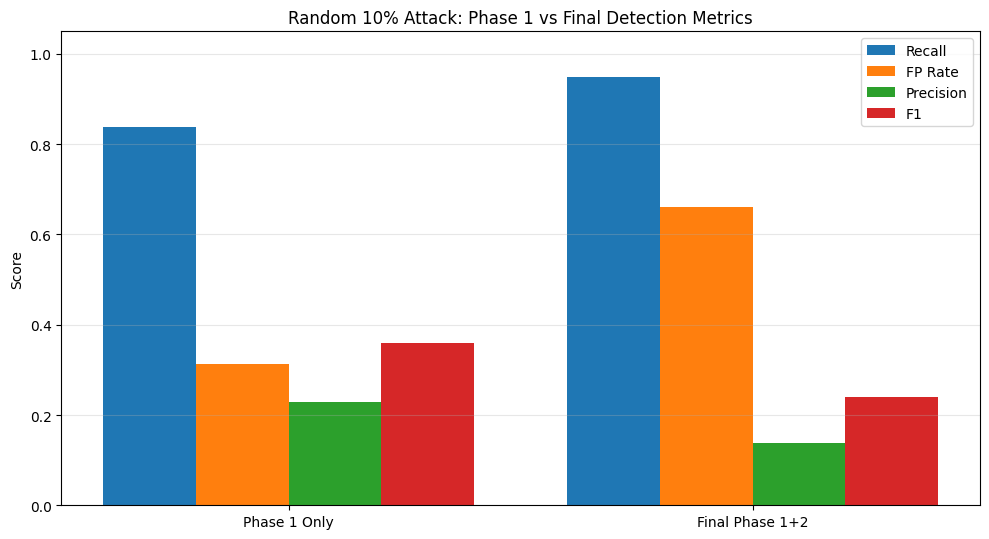


Saved:
random_10_lessstrict_phase1_vs_final_metrics.png
random_10_lessstrict_phase1_vs_final_metrics.pdf
random_10_lessstrict_summary_metrics.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Make sure det_df is already loaded
# det_df = pd.read_csv("uav_detection_random_10_lessstrict.csv")
# ============================================================

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))
    TP = int(np.sum((y_true == 1) & (y_pred == 1)))

    total = TN + FP + FN + TP

    accuracy = (TP + TN) / total if total > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if not np.isnan(precision) and not np.isnan(recall) and (precision + recall) > 0
        else np.nan
    )
    fp_rate = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    fn_rate = FN / (FN + TP) if (FN + TP) > 0 else np.nan

    return {
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fp_rate": fp_rate,
        "fn_rate": fn_rate,
    }


# ============================================================
# Compute dynamically
# ============================================================

y_true = det_df["actual_target_malicious"].astype(int)

phase1_metrics = compute_metrics(y_true, det_df["phase1_fail"].astype(int))
final_metrics = compute_metrics(y_true, det_df["final_flag"].astype(int))

metrics_df = pd.DataFrame([
    {
        "Method": "Phase 1 Only",
        "Recall": phase1_metrics["recall"],
        "FP Rate": phase1_metrics["fp_rate"],
        "Precision": phase1_metrics["precision"],
        "F1": phase1_metrics["f1"],
        "Accuracy": phase1_metrics["accuracy"],
    },
    {
        "Method": "Final Phase 1+2",
        "Recall": final_metrics["recall"],
        "FP Rate": final_metrics["fp_rate"],
        "Precision": final_metrics["precision"],
        "F1": final_metrics["f1"],
        "Accuracy": final_metrics["accuracy"],
    }
])

print("===== RANDOM 10% SUMMARY METRICS =====")
print(metrics_df)

metrics_df.to_csv("random_10_lessstrict_summary_metrics.csv", index=False)

# ============================================================
# Plot
# ============================================================

x = np.arange(len(metrics_df["Method"]))
width = 0.2

plt.figure(figsize=(10, 5.5))

plt.bar(x - 1.5*width, metrics_df["Recall"], width, label="Recall")
plt.bar(x - 0.5*width, metrics_df["FP Rate"], width, label="FP Rate")
plt.bar(x + 0.5*width, metrics_df["Precision"], width, label="Precision")
plt.bar(x + 1.5*width, metrics_df["F1"], width, label="F1")

plt.xticks(x, metrics_df["Method"])
plt.ylabel("Score")
plt.title("Random 10% Attack: Phase 1 vs Final Detection Metrics")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("random_10_lessstrict_phase1_vs_final_metrics.png", dpi=300)
plt.savefig("random_10_lessstrict_phase1_vs_final_metrics.pdf")
plt.show()

print("\nSaved:")
print("random_10_lessstrict_phase1_vs_final_metrics.png")
print("random_10_lessstrict_phase1_vs_final_metrics.pdf")
print("random_10_lessstrict_summary_metrics.csv")

## Dynamic environment breakdown plots

===== RANDOM 10% METRICS BY ENVIRONMENT =====
   envId     envName  phase1_recall  phase1_fp_rate  phase1_precision  \
0      0     Perfect       0.821126        0.085713          0.515606   
1      1        Open       0.832675        0.206165          0.309757   
2      2    Suburban       0.853289        0.370712          0.203664   
3      3  DenseUrban       0.849342        0.589474          0.138001   

   phase1_f1  final_recall  final_fp_rate  final_precision  final_f1  
0   0.633452      0.908480       0.155824         0.393129  0.548782  
1   0.451540      0.986404       0.816951         0.118289  0.211245  
2   0.328840      0.953289       0.834933         0.112580  0.201377  
3   0.237425      0.947003       0.837671         0.111595  0.199662  


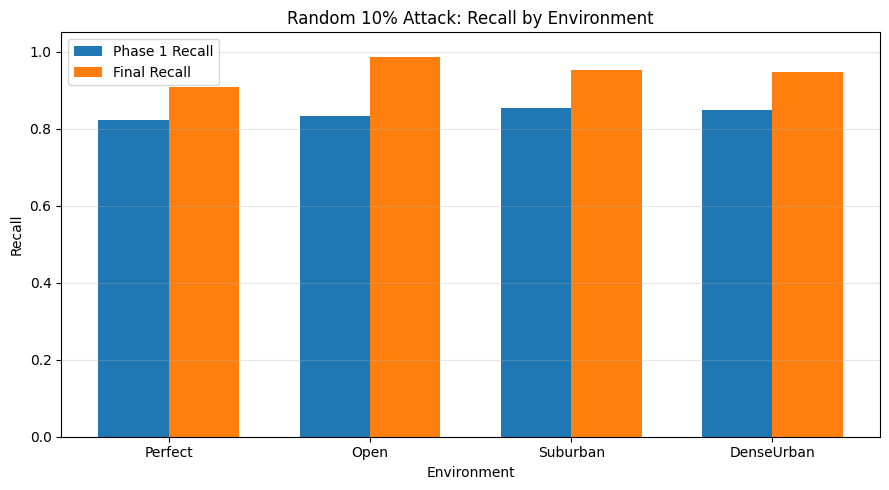

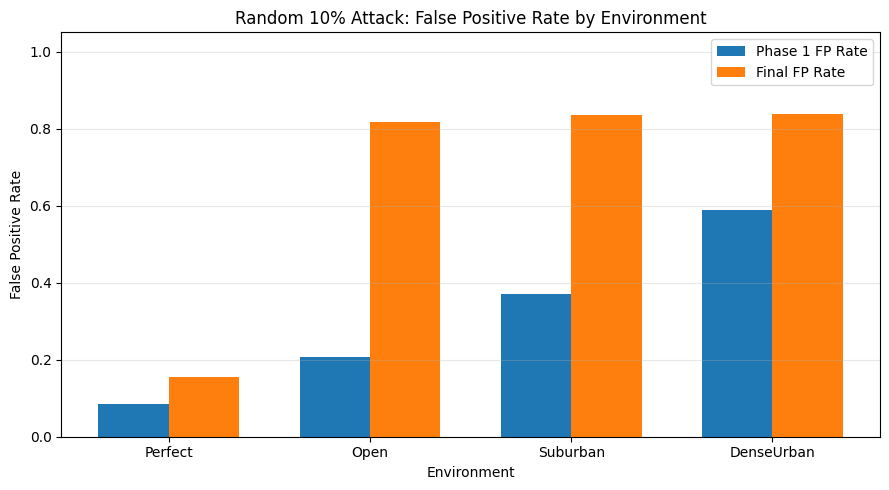


Saved:
random_10_lessstrict_metrics_by_environment.csv
random_10_lessstrict_recall_by_environment.png
random_10_lessstrict_recall_by_environment.pdf
random_10_lessstrict_fp_rate_by_environment.png
random_10_lessstrict_fp_rate_by_environment.pdf


In [6]:
# ============================================================
# Dynamic metrics by environment
# ============================================================

env_labels = {
    0: "Perfect",
    1: "Open",
    2: "Suburban",
    3: "DenseUrban"
}

rows = []

for env_id, sub in det_df.groupby("envId"):
    y_env = sub["actual_target_malicious"].astype(int)

    m_phase1 = compute_metrics(y_env, sub["phase1_fail"].astype(int))
    m_final = compute_metrics(y_env, sub["final_flag"].astype(int))

    rows.append({
        "envId": env_id,
        "envName": env_labels.get(env_id, str(env_id)),

        "phase1_recall": m_phase1["recall"],
        "phase1_fp_rate": m_phase1["fp_rate"],
        "phase1_precision": m_phase1["precision"],
        "phase1_f1": m_phase1["f1"],

        "final_recall": m_final["recall"],
        "final_fp_rate": m_final["fp_rate"],
        "final_precision": m_final["precision"],
        "final_f1": m_final["f1"],
    })

env_summary_dynamic = pd.DataFrame(rows).sort_values("envId")

print("===== RANDOM 10% METRICS BY ENVIRONMENT =====")
print(env_summary_dynamic)

env_summary_dynamic.to_csv("random_10_lessstrict_metrics_by_environment.csv", index=False)

# ============================================================
# Recall by environment
# ============================================================

plot_df = env_summary_dynamic.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    plot_df["phase1_recall"],
    width,
    label="Phase 1 Recall"
)

plt.bar(
    x + width/2,
    plot_df["final_recall"],
    width,
    label="Final Recall"
)

plt.xticks(x, plot_df["envName"])
plt.xlabel("Environment")
plt.ylabel("Recall")
plt.title("Random 10% Attack: Recall by Environment")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("random_10_lessstrict_recall_by_environment.png", dpi=300)
plt.savefig("random_10_lessstrict_recall_by_environment.pdf")
plt.show()

# ============================================================
# FP Rate by environment
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    plot_df["phase1_fp_rate"],
    width,
    label="Phase 1 FP Rate"
)

plt.bar(
    x + width/2,
    plot_df["final_fp_rate"],
    width,
    label="Final FP Rate"
)

plt.xticks(x, plot_df["envName"])
plt.xlabel("Environment")
plt.ylabel("False Positive Rate")
plt.title("Random 10% Attack: False Positive Rate by Environment")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("random_10_lessstrict_fp_rate_by_environment.png", dpi=300)
plt.savefig("random_10_lessstrict_fp_rate_by_environment.pdf")
plt.show()

print("\nSaved:")
print("random_10_lessstrict_metrics_by_environment.csv")
print("random_10_lessstrict_recall_by_environment.png")
print("random_10_lessstrict_recall_by_environment.pdf")
print("random_10_lessstrict_fp_rate_by_environment.png")
print("random_10_lessstrict_fp_rate_by_environment.pdf")

## |Dynamic recall vs FP tradeoff

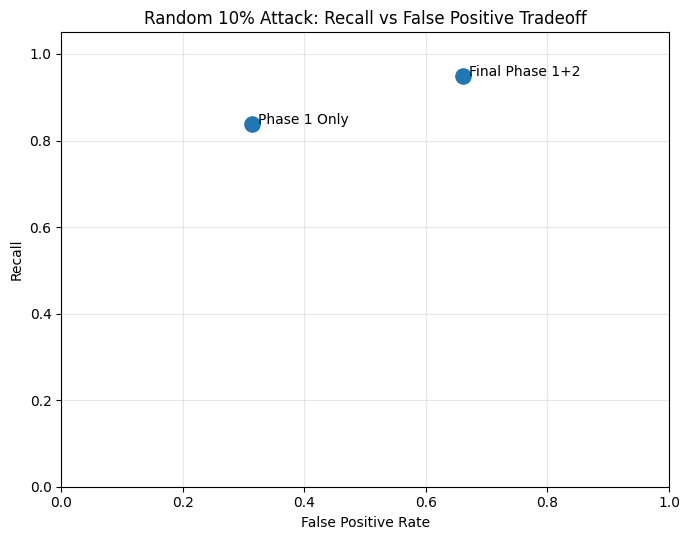

Saved:
random_10_lessstrict_recall_fp_tradeoff.png
random_10_lessstrict_recall_fp_tradeoff.pdf


In [7]:
# ============================================================
# Recall vs FP tradeoff
# ============================================================

plt.figure(figsize=(7, 5.5))

plt.scatter(
    metrics_df["FP Rate"],
    metrics_df["Recall"],
    s=120
)

for _, row in metrics_df.iterrows():
    plt.text(
        row["FP Rate"] + 0.01,
        row["Recall"],
        row["Method"],
        fontsize=10
    )

plt.xlabel("False Positive Rate")
plt.ylabel("Recall")
plt.title("Random 10% Attack: Recall vs False Positive Tradeoff")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("random_10_lessstrict_recall_fp_tradeoff.png", dpi=300)
plt.savefig("random_10_lessstrict_recall_fp_tradeoff.pdf")
plt.show()

print("Saved:")
print("random_10_lessstrict_recall_fp_tradeoff.png")
print("random_10_lessstrict_recall_fp_tradeoff.pdf")

In [8]:
pwd

'm:\\AIforCyberSecurity\\Project\\datsetgeneration\\malicious_data_generation\\maliciousdatagenerationlessstrict'

Models verification

In [9]:
from pathlib import Path

# ============================================================
# Current notebook/script location
# ============================================================

CURRENT_DIR = Path.cwd()

# Your current path:
# m:\AIforCyberSecurity\Project\datsetgeneration\malicious_data_generation\maliciousdatagenerationlessstrict
PROJECT_ROOT = CURRENT_DIR.parents[2]

print("===== PATH CHECK =====")
print("Current folder:", CURRENT_DIR)
print("Project root:", PROJECT_ROOT)

# ============================================================
# Dataset paths
# These should be in your current maliciousdatagenerationlessstrict folder
# ============================================================

det_path = CURRENT_DIR / "uav_detection_random_10_lessstrict.csv"
rl_path = CURRENT_DIR / "uav_rl_random_10_lessstrict.csv"

# ============================================================
# SAC model paths
# These should be in the organized project model folder
# ============================================================

model_path = PROJECT_ROOT / "models" / "sac_lam2_005" / "sac_model.zip"
vecnorm_path = PROJECT_ROOT / "models" / "sac_lam2_005" / "vecnormalize.pkl"

# ============================================================
# Check files
# ============================================================

paths_to_check = {
    "Detection CSV": det_path,
    "RL CSV": rl_path,
    "SAC model": model_path,
    "VecNormalize": vecnorm_path,
}

print("\n===== FILE EXISTS CHECK =====")
for name, path in paths_to_check.items():
    print(f"{name}: {path}")
    print("Exists:", path.exists())
    print()

===== PATH CHECK =====
Current folder: m:\AIforCyberSecurity\Project\datsetgeneration\malicious_data_generation\maliciousdatagenerationlessstrict
Project root: m:\AIforCyberSecurity\Project

===== FILE EXISTS CHECK =====
Detection CSV: m:\AIforCyberSecurity\Project\datsetgeneration\malicious_data_generation\maliciousdatagenerationlessstrict\uav_detection_random_10_lessstrict.csv
Exists: True

RL CSV: m:\AIforCyberSecurity\Project\datsetgeneration\malicious_data_generation\maliciousdatagenerationlessstrict\uav_rl_random_10_lessstrict.csv
Exists: True

SAC model: m:\AIforCyberSecurity\Project\models\sac_lam2_005\sac_model.zip
Exists: True

VecNormalize: m:\AIforCyberSecurity\Project\models\sac_lam2_005\vecnormalize.pkl
Exists: True



In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import gymnasium as gym
from gymnasium import spaces

# ============================================================
# Paths
# ============================================================

det_path = CURRENT_DIR / "uav_detection_random_10_lessstrict.csv"
rl_path = CURRENT_DIR / "uav_rl_random_10_lessstrict.csv"

model_path = PROJECT_ROOT / "models" / "sac_lam2_005" / "sac_model.zip"
vecnorm_path = PROJECT_ROOT / "models" / "sac_lam2_005" / "vecnormalize.pkl"

# ============================================================
# Load RL dataset
# ============================================================

rl_df = pd.read_csv(rl_path)

# Important: keep same sequential order as environment evaluation
rl_df = rl_df.sort_values(
    ["envId", "formationType", "timeStep", "receiverId"]
).reset_index(drop=True)

print("===== RL DATA LOADED =====")
print("Shape:", rl_df.shape)
print(rl_df.head())

# ============================================================
# Feature columns used during SAC training
# Same order as training
# ============================================================

feature_cols = [
    "sigma_rssi_bar",
    "sigma_gps_bar",
    "snr_bar",
    "plr_bar",
    "relative_speed_bar",
    "relative_height_bar",
    "trusted_count",
    "trust_bar",
    "theta"
]

# ============================================================
# Minimal dummy env for VecNormalize/SAC loading
# ============================================================

class DummyUAVEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(feature_cols),),
            dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=np.array([-2.0], dtype=np.float32),
            high=np.array([2.0], dtype=np.float32),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        obs = np.zeros(len(feature_cols), dtype=np.float32)
        return obs, {}

    def step(self, action):
        obs = np.zeros(len(feature_cols), dtype=np.float32)
        reward = 0.0
        terminated = False
        truncated = False
        info = {}
        return obs, reward, terminated, truncated, info

# ============================================================
# Load VecNormalize and SAC model
# ============================================================

base_env = DummyVecEnv([lambda: DummyUAVEnv()])
vec_env = VecNormalize.load(str(vecnorm_path), base_env)

vec_env.training = False
vec_env.norm_reward = False

model = SAC.load(str(model_path), env=vec_env)

print("\n===== MODEL LOADED =====")
print("Model:", model_path)
print("VecNormalize:", vecnorm_path)

# ============================================================
# Sequential SAC rollout
# ============================================================

Tmin = 1.0
Tmax = 50.0
initial_theta = 10.0

current_theta = initial_theta
dynamic_rows = []

for idx, row in rl_df.iterrows():

    # Build observation from row
    obs = row[feature_cols].to_numpy(dtype=np.float32)

    # IMPORTANT:
    # Replace static theta with current dynamic theta
    obs[-1] = current_theta

    obs = obs.reshape(1, -1)

    # Normalize using training VecNormalize statistics
    obs_norm = vec_env.normalize_obs(obs)

    # SAC predicts threshold adjustment
    action, _ = model.predict(obs_norm, deterministic=True)

    delta_T = float(action[0][0])

    old_theta = current_theta
    current_theta = float(np.clip(current_theta + delta_T, Tmin, Tmax))

    dynamic_rows.append({
        "envId": int(row["envId"]),
        "formationType": int(row["formationType"]),
        "timeStep": int(row["timeStep"]),
        "receiverId": int(row["receiverId"]),
        "old_theta": old_theta,
        "delta_T": delta_T,
        "dynamic_theta": current_theta
    })

dynamic_theta_seq_df = pd.DataFrame(dynamic_rows)

print("\n===== SEQUENTIAL DYNAMIC THRESHOLD GENERATED =====")
print("Shape:", dynamic_theta_seq_df.shape)
print(dynamic_theta_seq_df.head())

print("\n===== SEQUENTIAL DYNAMIC THRESHOLD SUMMARY BY ENV =====")
print(dynamic_theta_seq_df.groupby("envId")["dynamic_theta"].describe())

print("\n===== SEQUENTIAL DYNAMIC THRESHOLD SUMMARY BY ENV + FORMATION =====")
print(dynamic_theta_seq_df.groupby(["envId", "formationType"])["dynamic_theta"].describe())

# Save
out_path = CURRENT_DIR / "random_10_sac_dynamic_thresholds_sequential.csv"
dynamic_theta_seq_df.to_csv(out_path, index=False)

print("\nSaved:")
print(out_path)

===== RL DATA LOADED =====
Shape: (28800, 14)
   envId  formationType  timeStep  receiverId  sigma_rssi_bar  sigma_gps_bar  \
0      0              0         1           1     1876.325174    1876.325174   
1      0              0         1           2       66.082759       0.443022   
2      0              0         1           3     1618.386016    1618.386016   
3      0              0         1           4     1615.630127    1615.630127   
4      0              0         1           5     1414.140220    1414.140220   

   snr_bar   plr_bar  relative_speed_bar  relative_height_bar  trusted_count  \
0    100.0  0.096275                 0.0             3.576436             17   
1    100.0  0.048041                 0.0             7.105646              3   
2    100.0  0.067723                 0.0             4.827881             16   
3    100.0  0.064105                 0.0             4.499966             17   
4    100.0  0.055470                 0.0             4.047224            

## merge SAC threshold and compare methods

In [12]:
import pandas as pd
import numpy as np

# ============================================================
# Load detection dataset and sequential dynamic threshold table
# ============================================================

det_df = pd.read_csv(det_path)

dynamic_theta_seq_df = pd.read_csv(
    CURRENT_DIR / "random_10_sac_dynamic_thresholds_sequential.csv"
)

print("===== LOADED =====")
print("Detection shape:", det_df.shape)
print("Sequential dynamic theta shape:", dynamic_theta_seq_df.shape)

# ============================================================
# Merge dynamic threshold into detection rows
# ============================================================

merge_keys = ["envId", "formationType", "timeStep", "receiverId"]

det_dyn = det_df.merge(
    dynamic_theta_seq_df[merge_keys + ["dynamic_theta"]],
    on=merge_keys,
    how="left"
)

print("\n===== MERGE CHECK =====")
print("Merged shape:", det_dyn.shape)
print("Missing dynamic theta:", det_dyn["dynamic_theta"].isna().sum())

if det_dyn["dynamic_theta"].isna().sum() > 0:
    raise ValueError("Some detection rows did not get a dynamic threshold.")

# ============================================================
# Prediction columns
# ============================================================

det_dyn["static_phase1_pred"] = (det_dyn["delta_d"] > 10).astype(int)

det_dyn["sac_dynamic_phase1_pred"] = (
    det_dyn["delta_d"] > det_dyn["dynamic_theta"]
).astype(int)

det_dyn["static_final_pred"] = det_dyn["final_flag"].astype(int)

y_true = det_dyn["actual_target_malicious"].astype(int)

# ============================================================
# Metric function
# ============================================================

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))
    TP = int(np.sum((y_true == 1) & (y_pred == 1)))

    total = TN + FP + FN + TP

    accuracy = (TP + TN) / total if total > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if not np.isnan(precision) and not np.isnan(recall) and (precision + recall) > 0
        else np.nan
    )
    fp_rate = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    fn_rate = FN / (FN + TP) if (FN + TP) > 0 else np.nan

    return {
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fp_rate": fp_rate,
        "fn_rate": fn_rate,
    }

# ============================================================
# Compare methods
# ============================================================

methods = {
    "Static Phase 1 θ=10": det_dyn["static_phase1_pred"],
    "SAC Dynamic Phase 1": det_dyn["sac_dynamic_phase1_pred"],
    "Static Final Phase 1+2": det_dyn["static_final_pred"],
}

rows = []

for method_name, y_pred in methods.items():
    m = compute_metrics(y_true, y_pred)
    rows.append({"method": method_name, **m})

comparison_df = pd.DataFrame(rows)

print("\n===== STATIC VS SAC DYNAMIC COMPARISON =====")
print(comparison_df)

comparison_df.to_csv(
    CURRENT_DIR / "random_10_static_vs_sac_dynamic_sequential_comparison.csv",
    index=False
)

det_dyn.to_csv(
    CURRENT_DIR / "uav_detection_random_10_lessstrict_with_sac_theta_sequential.csv",
    index=False
)

print("\nSaved:")
print(CURRENT_DIR / "random_10_static_vs_sac_dynamic_sequential_comparison.csv")
print(CURRENT_DIR / "uav_detection_random_10_lessstrict_with_sac_theta_sequential.csv")

===== LOADED =====
Detection shape: (547200, 19)
Sequential dynamic theta shape: (28800, 7)

===== MERGE CHECK =====
Merged shape: (547200, 20)
Missing dynamic theta: 0

===== STATIC VS SAC DYNAMIC COMPARISON =====
                   method      TN      FP     FN     TP  accuracy  precision  \
0     Static Phase 1 θ=10  338326  154154   8804  45916  0.702197   0.229500   
1     SAC Dynamic Phase 1  420444   72036  14112  40608  0.842566   0.360499   
2  Static Final Phase 1+2  166781  325699   2802  51918  0.399669   0.137489   

     recall        f1   fp_rate   fn_rate  
0  0.839108  0.360422  0.313016  0.160892  
1  0.742105  0.485266  0.146272  0.257895  
2  0.948794  0.240174  0.661345  0.051206  

Saved:
m:\AIforCyberSecurity\Project\datsetgeneration\malicious_data_generation\maliciousdatagenerationlessstrict\random_10_static_vs_sac_dynamic_sequential_comparison.csv
m:\AIforCyberSecurity\Project\datsetgeneration\malicious_data_generation\maliciousdatagenerationlessstrict\uav_dete

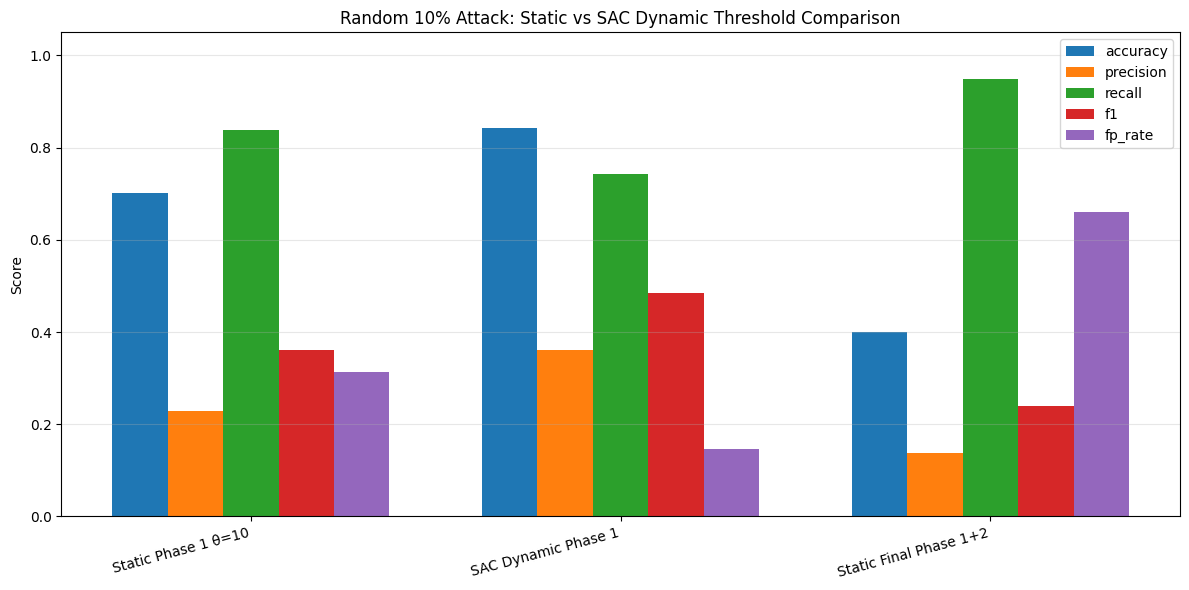

Saved:
random_10_static_vs_sac_dynamic_comparison.png
random_10_static_vs_sac_dynamic_comparison.pdf


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# comparison_df already exists from previous cell
plot_df = comparison_df.copy()

metrics_to_plot = ["accuracy", "precision", "recall", "f1", "fp_rate"]

x = np.arange(len(plot_df["method"]))
width = 0.15

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics_to_plot):
    plt.bar(
        x + (i - 2) * width,
        plot_df[metric],
        width,
        label=metric
    )

plt.xticks(x, plot_df["method"], rotation=15, ha="right")
plt.ylabel("Score")
plt.title("Random 10% Attack: Static vs SAC Dynamic Threshold Comparison")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("random_10_static_vs_sac_dynamic_comparison.png", dpi=300)
plt.savefig("random_10_static_vs_sac_dynamic_comparison.pdf")
plt.show()

print("Saved:")
print("random_10_static_vs_sac_dynamic_comparison.png")
print("random_10_static_vs_sac_dynamic_comparison.pdf")

## environment-level Static vs SAC

===== STATIC VS SAC BY ENVIRONMENT =====
   envId     envName  static_accuracy  static_precision  static_recall  \
0      0     Perfect         0.904971          0.515606       0.821126   
1      1        Open         0.797719          0.309757       0.832675   
2      2    Suburban         0.651689          0.203664       0.853289   
3      3  DenseUrban         0.454408          0.138001       0.849342   

   static_f1  static_fp_rate  sac_accuracy  sac_precision  sac_recall  \
0   0.633452        0.085713      0.905702       0.515126    0.970906   
1   0.451540        0.206165      0.838458       0.358137    0.776827   
2   0.328840        0.370712      0.822946       0.320395    0.687281   
3   0.237425        0.589474      0.803158       0.262086    0.533406   

     sac_f1  sac_fp_rate  
0  0.673120     0.101543  
1  0.490254     0.154695  
2  0.437048     0.161980  
3  0.351476     0.166870  


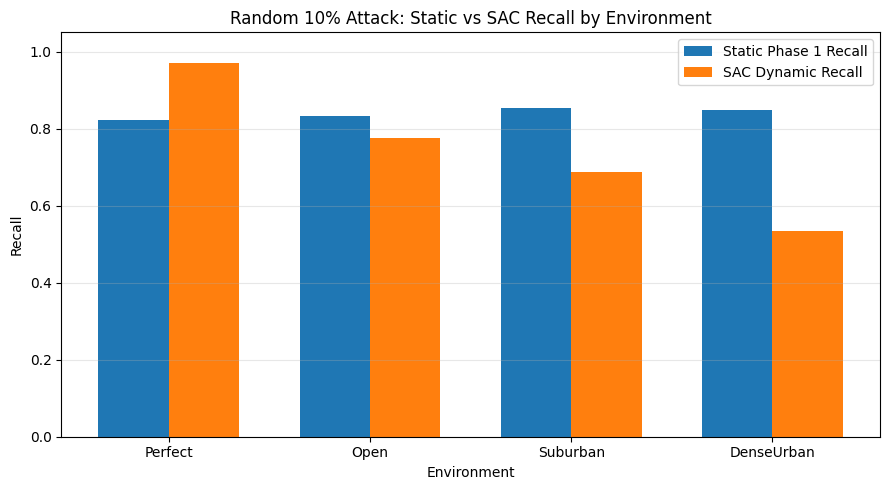

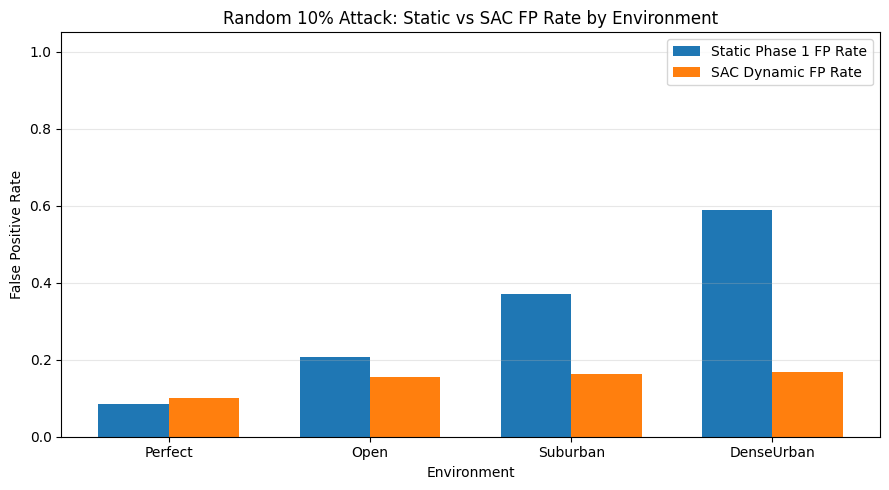


Saved:
random_10_static_vs_sac_by_environment.csv
random_10_static_vs_sac_recall_by_environment.png
random_10_static_vs_sac_fp_rate_by_environment.png


In [14]:
# ============================================================
# Static vs SAC Dynamic Phase 1 by environment
# ============================================================

env_labels = {
    0: "Perfect",
    1: "Open",
    2: "Suburban",
    3: "DenseUrban"
}

rows = []

for env_id, sub in det_dyn.groupby("envId"):
    y_env = sub["actual_target_malicious"].astype(int)

    m_static = compute_metrics(y_env, sub["static_phase1_pred"].astype(int))
    m_sac = compute_metrics(y_env, sub["sac_dynamic_phase1_pred"].astype(int))

    rows.append({
        "envId": env_id,
        "envName": env_labels.get(env_id, str(env_id)),

        "static_accuracy": m_static["accuracy"],
        "static_precision": m_static["precision"],
        "static_recall": m_static["recall"],
        "static_f1": m_static["f1"],
        "static_fp_rate": m_static["fp_rate"],

        "sac_accuracy": m_sac["accuracy"],
        "sac_precision": m_sac["precision"],
        "sac_recall": m_sac["recall"],
        "sac_f1": m_sac["f1"],
        "sac_fp_rate": m_sac["fp_rate"],
    })

env_static_sac_df = pd.DataFrame(rows)

print("===== STATIC VS SAC BY ENVIRONMENT =====")
print(env_static_sac_df)

env_static_sac_df.to_csv(
    CURRENT_DIR / "random_10_static_vs_sac_by_environment.csv",
    index=False
)

# ============================================================
# Plot 1: Recall by environment
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plot_df = env_static_sac_df.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    plot_df["static_recall"],
    width,
    label="Static Phase 1 Recall"
)

plt.bar(
    x + width/2,
    plot_df["sac_recall"],
    width,
    label="SAC Dynamic Recall"
)

plt.xticks(x, plot_df["envName"])
plt.xlabel("Environment")
plt.ylabel("Recall")
plt.title("Random 10% Attack: Static vs SAC Recall by Environment")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("random_10_static_vs_sac_recall_by_environment.png", dpi=300)
plt.savefig("random_10_static_vs_sac_recall_by_environment.pdf")
plt.show()

# ============================================================
# Plot 2: FP rate by environment
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    plot_df["static_fp_rate"],
    width,
    label="Static Phase 1 FP Rate"
)

plt.bar(
    x + width/2,
    plot_df["sac_fp_rate"],
    width,
    label="SAC Dynamic FP Rate"
)

plt.xticks(x, plot_df["envName"])
plt.xlabel("Environment")
plt.ylabel("False Positive Rate")
plt.title("Random 10% Attack: Static vs SAC FP Rate by Environment")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("random_10_static_vs_sac_fp_rate_by_environment.png", dpi=300)
plt.savefig("random_10_static_vs_sac_fp_rate_by_environment.pdf")
plt.show()

print("\nSaved:")
print("random_10_static_vs_sac_by_environment.csv")
print("random_10_static_vs_sac_recall_by_environment.png")
print("random_10_static_vs_sac_fp_rate_by_environment.png")